In [20]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
import torch
from tqdm.auto import tqdm
from torch.optim import Adam
import numpy as np
import numpy.typing as npt
from utils import make_unpacked_configurations
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import torch
import torch.nn as nn
import torch.nn.functional as F
from gcnn_naive import GConvLattice, GConvG, SplitGroupConvNet2, SplitGroupResConvNet

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt

from sympy.combinatorics import Permutation
from sympy.combinatorics.perm_groups import PermutationGroup

from collections.abc import Iterable
import itertools
import functools
import operator
from utils import one


In [21]:
def train_test_split(X: torch.Tensor, Y: torch.Tensor, train_ratio=0.8):
    N = len(Y)
    train_size = int(N * train_ratio)
    idxs = np.arange(N)
    np.random.shuffle(idxs)
    train_idxs = idxs[:train_size]
    test_idxs = idxs[train_size:]
    return X[train_idxs], Y[train_idxs], X[test_idxs], Y[test_idxs]

In [22]:
def inv_perm(perm: list[int]) -> list[int]:
    return (~Permutation(perm)).array_form

In [23]:
# X = torch.tensor(
#     make_unpacked_configurations(
#         system.basis.states[:10], number_spins=system.number_spins
#     ).astype(np.float32),
# )

# # filter_idxs = [
# #     group_elements.index(tx**a * ty**b * sym**c)
# #     for a, b, c in itertools.product(range(2), range(2), range(2))
# # ]
# filter_idxs = torch.arange(12)

# layer = GConvGrid(
#     group_elements=group_elements,
#     filter_idxs=filter_idxs,
#     out_channels=3,
# )
# layer(X)
# assert torch.allclose(layer(X), layer._forward_reference(X), atol=1e-7)

In [24]:
lattice = KagomeLattice(2, 3, enumerate_along="x")
system = HeisenbergJ1J2(
    lattice=lattice,
    J2=0.8,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True,
)
system.get_eigenstates(1)

2023-07-04 15:42:24.163 | WARNING  | heisenberg_hamiltonians:__init__:424 - Symmetries are not tested with KagomeLattice2x3-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-07-04 15:42:24.168 | DEBUG    | heisenberg_hamiltonians:__init__:456 - number_spins=18
2023-07-04 15:42:24.173 | DEBUG    | heisenberg_hamiltonians:__init__:466 - Symmetry group contains 12 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-07-04 15:42:24.221 | DEBUG    | heisenberg_hamiltonians:__init__:475 - Hilbert space dimension is 2102
2023-07-04 15:42:24.252 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:64 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-enumerate-along-x-1.0-0.8-True-1-1.pickle
2023-07-04 15:42:24.259 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:111 - Ground state energy is -29.4963743253


(array([-29.49637433]),
 array([[ 2.45861402e-05],
        [ 4.60301334e-05],
        [-5.98187546e-05],
        ...,
        [ 3.85816233e-03],
        [-1.34561320e-02],
        [ 4.54259634e-02]]))

In [25]:
group_elements = [Permutation(g) for g in sorted(lattice.get_automorphisms())]
tx = Permutation(lattice.get_translation("x"))
ty = Permutation(lattice.get_translation("y"))
sym = one(
    g
    for g in group_elements
    if g.apply(0) == 0 and any(g.apply(x) != x for x in range(lattice.number_spins))
)
filter_idxs_2 = [
    group_elements.index(tx**a * ty**b * sym**c)
    for a, b, c in itertools.product(range(2), range(2), range(2))
]

In [26]:
X = torch.tensor(
    make_unpacked_configurations(
        system.basis.states[:10], number_spins=system.number_spins
    ).astype(np.float32),
)

In [27]:
# layer1 = GConvLattice(group_elements=group_elements, filter_idxs=torch.arange(12), out_channels=3)
# layer2 = GConvG(
#     group_elements=group_elements, filter_idxs=filter_idxs_2, in_channels=3, out_channels=5
# )

# # assert equivariance
# X = torch.tensor(
#     make_unpacked_configurations(system.basis.states, number_spins=system.number_spins).astype(
#         np.float32
#     ),
# )


# def net(X):
#     return layer2(layer1(X))


# def net_reference(X):
#     return layer2._forward_reference(layer1(X))


# assert net(X).shape == (len(system.basis.states), 5, len(group_elements))
# assert torch.allclose(net(X), net_reference(X), atol=1e-6)
# for action in group_elements:
#     assert torch.allclose(
#         torch.relu(net(X[:, (~action).array_form])),
#         torch.relu(net(X)[:, :, self_action(~action, group_elements).array_form]),
#         atol=1e-6,
#     )

In [28]:
def find_fundamental_domain(group_elements: list[Permutation]):
    site = 0
    remaining_sites = set(group_elements[0].array_form)
    fundamental_domain = [site]
    while True:
        remaining_sites -= set(g.apply(site) for g in group_elements)
        if not remaining_sites:
            break
        site = remaining_sites.pop()
        fundamental_domain.append(site)
        
    return fundamental_domain

In [29]:
find_fundamental_domain(
    [Permutation(g) for g in KagomeLattice(2, 3).get_automorphisms()]
)

[0, 1, 3]

In [30]:
group_elements = set(Permutation(g) for g in lattice.get_automorphisms())

In [31]:
(
    group_elements
    - PermutationGroup(
        Permutation(lattice.get_translation("x")), Permutation(lattice.get_translation("y"))
    ).elements
)

{Permutation(0, 14)(1, 13)(2, 12)(3, 15)(4, 11)(5, 10)(6, 8)(16, 17),
 Permutation(0, 2)(4, 17)(5, 16)(6, 14)(7, 13)(8, 12)(9, 15)(10, 11),
 Permutation(0, 6)(1, 9)(2, 8)(3, 7)(10, 16)(11, 17)(13, 15),
 Permutation(0, 8)(1, 7)(2, 6)(3, 9)(4, 5)(10, 17)(11, 16)(12, 14),
 Permutation(1, 3)(4, 16)(5, 17)(6, 12)(7, 15)(8, 14)(9, 13),
 Permutation(17)(0, 12)(1, 15)(2, 14)(3, 13)(4, 10)(5, 11)(7, 9)}

In [32]:
vis_permutation(lattice, [x for x in group_elements if x.apply(0) == 0][2].array_form)

NameError: name 'vis_permutation' is not defined

In [33]:
find_fundamental_domain(
    list(
        PermutationGroup(
            [
                Permutation(x)
                for x in [
                    KagomeLattice(4, 4).get_translation("x"),
                    KagomeLattice(4, 4).get_translation("y"),
                ]
            ]
        ).elements
    )
)

[0, 1, 3]

In [34]:
translation_group = PermutationGroup(tx, ty)
fundamental_domain = find_fundamental_domain(list(translation_group.elements))


In [35]:
class TranslationPlusConvNet2(nn.Module):
    def __init__(
        self,
        tx: Permutation,
        ty: Permutation,
        additional_generators: list[Permutation] | None = None,
        filter_width=2,
        filter_height=2,
        channels1=32,
        channels2=64,
    ):
        if additional_generators is None:
            additional_generators = []

        super().__init__()


        generators = [tx, ty] + additional_generators
        group_elements: list[Permutation] = sorted(
            list(PermutationGroup(*generators).elements), key=lambda g: tuple(g.array_form)
        )

        filter_idxs_1 = [
            int((tx**a * ty**b).apply(site))
            for site in fundamental_domain
            for a in range(filter_width)
            for b in range(filter_height)
        ]

        self.group_elements = group_elements


        self.layer1 = GConvLattice(
            group_elements=group_elements, filter_idxs=filter_idxs_1, out_channels=channels1
        )

        filter_idxs_2 = [
            group_elements.index(
                mult_comb([tx, ty] + additional_generators, [x_deg, y_deg] + additional_deg)
            )
            for x_deg, y_deg, *additional_deg in itertools.product(
                range(filter_width),
                range(filter_height),
                *[range(int(g.order())) for g in additional_generators]
            )
        ]

        self.layer2 = GConvG(
            group_elements=group_elements,
            filter_idxs=filter_idxs_2,
            in_channels=channels1,
            out_channels=channels2,
        )

        self.fc = nn.Linear(channels2, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        x = torch.relu(x)
        x = x.mean(dim=2)
        x = self.fc(x)
        return x

In [36]:
def get_X_Y(system: SpinSystem, sample=None, target="amplitude"):
    ground_state_df = system.get_df_ground_state()
    if sample:
        ground_state_df = ground_state_df.sample(sample)
    Y = torch.Tensor(
        np.log(np.real_if_close(ground_state_df[target].to_numpy()).astype(np.float32))
    )
    X = torch.Tensor(
        make_unpacked_configurations(
            ground_state_df.index.to_numpy(), number_spins=system.number_spins
        ).astype(np.float32)
    )
    return X, Y


def overlap(x, y):
    return torch.sum(x * y) / torch.sqrt(torch.sum(x**2) * torch.sum(y**2))

In [37]:
lattice = KagomeLattice(3, 3, enumerate_along="x")
system = HeisenbergJ1J2(
    lattice=lattice,
    J2=0.8,
    use_symmetries=True,
    spin_inversion=None,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True
)
system.get_eigenstates(1)

2023-07-04 15:42:28.273 | WARNING  | heisenberg_hamiltonians:__init__:424 - Symmetries are not tested with KagomeLattice3x3-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-07-04 15:42:28.274 | DEBUG    | heisenberg_hamiltonians:__init__:456 - number_spins=27
2023-07-04 15:42:28.287 | DEBUG    | heisenberg_hamiltonians:__init__:466 - Symmetry group contains 36 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-07-04 15:42:28.560 | DEBUG    | heisenberg_hamiltonians:__init__:475 - Hilbert space dimension is 558660
2023-07-04 15:42:28.573 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:64 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice3x3-enumerate-along-x-1.0-0.8-True-None-1.pickle
2023-07-04 15:42:28.582 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:111 - Ground state energy is -44.4794737053


(array([-44.47947371]),
 array([[ 4.02935217e-08],
        [-3.87679529e-08],
        [-7.97444500e-08],
        ...,
        [-6.33880544e-04],
        [ 1.42378516e-03],
        [-1.11709382e-03]]))

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

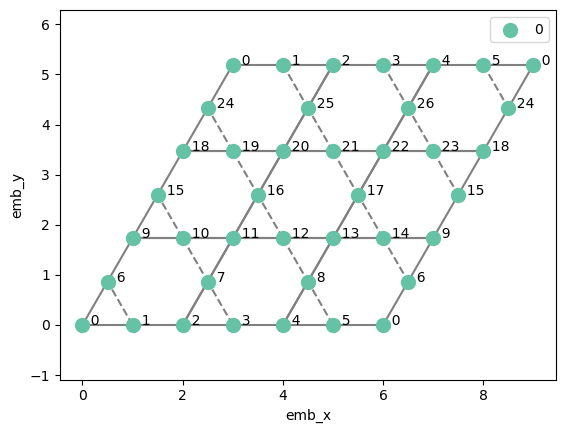

In [38]:
lattice.plot()

In [40]:
# # Test invariance

# X, Y = get_X_Y(system, sample=1000)

# model = TranslationPlusConvNet2(
#     tx=Permutation(lattice.get_translation("x")),
#     ty=Permutation(lattice.get_translation("y")),
#     additional_generators=[sym1, sym2],
#     channels1=3,
#     channels2=5,
# )

# for g in model.group_elements:
#     assert torch.allclose(model(X[:, g.array_form]), model(X[:]), atol=1e-6)

In [41]:
# lattice.plot(spins=np.isin(np.arange(lattice.number_spins), model.layer1.filter_idxs))

NameError: name 'model' is not defined

In [ ]:
# model.layer2.filter_idxs

[0, 3, 2, 1, 13, 11, 6, 26, 5, 24, 15, 8, 18, 32, 19, 33]

In [42]:
J2 = 0.8
lattice = KagomeLattice(2, 2, enumerate_along="x")
system = HeisenbergJ1J2(
    lattice=lattice,
    J2=J2,
    use_symmetries=True,
    spin_inversion=None,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True,
)
system.get_eigenstates(1)

lattice_target = KagomeLattice(3, 3, enumerate_along="x")
system_target = HeisenbergJ1J2(
    lattice=lattice_target,
    J2=J2,
    use_symmetries=True,
    spin_inversion=None,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True,
)
system_target.get_eigenstates(1)

2023-07-04 15:43:05.223 | WARNING  | heisenberg_hamiltonians:__init__:424 - Symmetries are not tested with KagomeLattice2x2-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-07-04 15:43:05.223 | DEBUG    | heisenberg_hamiltonians:__init__:456 - number_spins=12
2023-07-04 15:43:05.228 | DEBUG    | heisenberg_hamiltonians:__init__:466 - Symmetry group contains 16 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-07-04 15:43:05.256 | DEBUG    | heisenberg_hamiltonians:__init__:475 - Hilbert space dimension is 76
2023-07-04 15:43:05.277 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:64 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-enumerate-along-x-1.0-0.8-True-None-1.pickle
2023-07-04 15:43:05.290 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:111 - Ground state energy is -20.0382298203
2023-07-04 15:43:05.330 | WARNING  | heisenberg_hamiltonians:__init__:424 - Symmetries are not tested with KagomeLattice3x3-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-07-04 15:43:05.331 | DEBUG    | heisenberg_hamiltonians:__init__:456 - number_spins=27
2023-07-04 15:43:05.339 | DEBUG    | heisenberg_hamiltonians:__init__:466 - Symmetry group contains 36 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate

(array([-44.47947371]),
 array([[ 4.02935217e-08],
        [-3.87679529e-08],
        [-7.97444500e-08],
        ...,
        [-6.33880544e-04],
        [ 1.42378516e-03],
        [-1.11709382e-03]]))

In [43]:
X, Y, X_test, Y_test = train_test_split(*get_X_Y(system), train_ratio=0.8)
X_target, Y_target = get_X_Y(system_target, sample=10000)


2023-07-04 15:43:07.418 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:218 - Finding basis_state_info
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-07-04 15:43:07.430 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:221 - Finding corresp_repr_indices
2023-07-04 15:43:07.430 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:227 - Finding coeffs
2023-07-04 15:43:07.437 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:218 - Finding basis_state_info
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-07-04 15:43:13.023 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:221 - Finding corresp_repr_indices
2023-07-04 15:43:13.321 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:227 - Finding coeffs


In [ ]:
name_to_symmetry = {
    "sym1": Permutation(one([g for g in lattice.get_automorphisms() if g[0] == 0 and g[1] == 4])),
    "sym2": Permutation(one([g for g in lattice.get_automorphisms() if g[0] == 0 and g[1] == 10])),
}

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

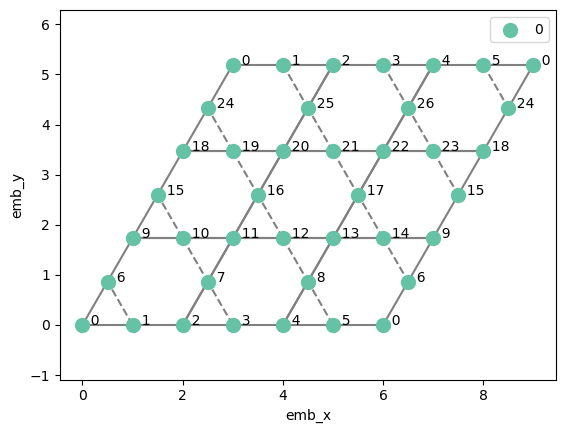

In [ ]:
lattice_target.plot()

In [ ]:
name_to_symmetry_target = dict(
    sym1=Permutation(
        one([g for g in lattice_target.get_automorphisms() if g[0] == 0 and g[1] == 6])
    ),
    sym2=Permutation(
        one([g for g in lattice_target.get_automorphisms() if g[0] == 0 and g[1] == 24])
    ),
)

In [121]:
from torch.utils.tensorboard import SummaryWriter

# Initialize the model
channels1 = 16
channels2 = 32
symmetries = ['sym1', 'sym2']

lr = 1e-5

model = TranslationPlusConvNet2(
    tx=Permutation(lattice.get_translation("x")),
    ty=Permutation(lattice.get_translation("y")),
    additional_generators=[name_to_symmetry[s] for s in symmetries],
    channels1=channels1,
    channels2=channels2,
)

model_target = TranslationPlusConvNet2(
    tx=Permutation(lattice_target.get_translation("x")),
    ty=Permutation(lattice_target.get_translation("y")),
    additional_generators=[name_to_symmetry_target[s] for s in symmetries],
    channels1=channels1,
    channels2=channels2,
)

# Check if a GPU is available and if not, use a CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Move the model to the device (GPU or CPU)
model.to(device)

# Create a TensorDataset from your inputs X and Y
dataset = TensorDataset(X, Y)

# Create a DataLoader for your dataset with a batch size of 32 and shuffling
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define a loss function - Mean Squared Error (MSE) for regression
criterion = torch.nn.MSELoss()

# Define an optimizer - Adam
optimizer = optim.Adam(model.parameters(), lr=lr)  # Learning rate

# Number of epochs (iterations over the entire dataset)
epochs = 5000

# Create a SummaryWriter instance for TensorBoard
writer = SummaryWriter(
        log_dir=(
            f"experiments/2023_06_27/{datetime.now().strftime('%H_%M_%S')}"
            f"_{channels1=}_{channels2=}_{','.join(symmetries)}_{lr=}"
        )
    )
for epoch in range(epochs):
    running_loss = 0.0
    for action_index, data in enumerate(dataloader, 0):
        # Get the inputs and move them to the specified device
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = criterion(outputs, labels.view(-1, 1))  # Reshape labels to match output shape

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Collect loss
        running_loss += loss.item()

    # Add average loss per epoch to TensorBoard
    writer.add_scalar('Training Loss', running_loss / len(dataloader), epoch)
    
    # Calculate overlaps and add them to TensorBoard
    overlap_train = overlap(torch.exp(model(X).view(-1)), torch.exp(Y))
    overlap_test = overlap(torch.exp(model(X_test).view(-1)), torch.exp(Y_test))
    model_target.load_state_dict(model.state_dict())
    overlap_target = overlap(torch.exp(model_target(X_target).view(-1)), torch.exp(Y_target))
    
    writer.add_scalar('Overlap Train', overlap_train, epoch)
    writer.add_scalar('Overlap Test', overlap_test, epoch)
    writer.add_scalar('Overlap Target', overlap_target, epoch)

writer.close()
print("Finished Training")


KeyboardInterrupt: 